# 01 — A minimal PINN from scratch

**Making PINNs Work** · Prof. Dr. Dmitry Mikhaylov

Plain PyTorch. No PINN library, no hidden machinery — you see every line that makes a
physics-informed network work.

We solve the viscous Burgers equation, the standard first benchmark in this field:

$$u_t + u\,u_x - \nu\,u_{xx} = 0, \qquad x \in [-1, 1],\; t \in [0, 1]$$
$$u(0, x) = -\sin(\pi x), \qquad u(t, -1) = u(t, 1) = 0, \qquad \nu = 0.01/\pi$$

A smooth sine steepens into a near-discontinuity at $x=0$. That steepening is what makes
it a useful first test: a method that cannot resolve it looks fine on the loss curve and
wrong in the picture.

Crucially, **this problem has a closed-form solution**, so we can measure real error
rather than guess from the loss. Most tutorials skip that step. We do it in this very
first module, because it is the habit the whole course is about.

Formulation: Raissi, Perdikaris & Karniadakis, *J. Comput. Phys.* **378** (2019) 686–707.

In [1]:
"""Module 01 - A minimal PINN from scratch: Burgers' equation.
u_t + u*u_x - nu*u_xx = 0,  x in [-1,1], t in [0,1]
u(0,x) = -sin(pi x),  u(t,-1) = u(t,1) = 0,  nu = 0.01/pi
"""
import time
import numpy as np
import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)
NU = 0.01 / np.pi

## The exact solution

The Cole–Hopf transformation linearises Burgers' equation, and for this initial data it
gives a closed form. Because $-\sin(\pi x)$ is odd and 2-periodic, the whole-line
solution automatically satisfies $u(t,\pm 1)=0$ — so it solves our Dirichlet problem too.

The exponent reaches about 50 here, so the integrals overflow unless you subtract the
maximum before exponentiating. That one line is the difference between a working
reference and a screen of `nan`.

In [2]:
def burgers_exact(x, t, n_quad=20001, span=12.0):
    """Exact solution via the Cole-Hopf transformation - our ground truth.

    For u(0,x) = -sin(pi x) the transformation gives a closed form:

        u(x,t) = -int sin(pi(x-e)) F(x-e) G(e) de / int F(x-e) G(e) de
        F(y) = exp(-cos(pi y) / (2 pi nu)),   G(e) = exp(-e^2 / (4 nu t))

    Because the initial data is odd and 2-periodic, this whole-line solution
    satisfies u(t,+-1) = 0 exactly, so it is the solution of our problem too.
    The exponent reaches ~50 here, so we subtract its maximum before
    exponentiating; without that the integrals overflow.
    """
    x = np.atleast_1d(np.asarray(x, dtype=float)).ravel()
    e = np.linspace(-span, span, n_quad)
    out = np.empty_like(x)
    for i, xi in enumerate(x):
        y = xi - e
        E = -np.cos(np.pi * y) / (2 * np.pi * NU) - e ** 2 / (4 * NU * t)
        w = np.exp(E - E.max())
        out[i] = -np.sum(np.sin(np.pi * y) * w) / np.sum(w)
    return out

## The network

An ordinary fully connected network taking $(t,x)$ and returning $u$. Nothing in the
architecture knows any physics — the physics lives entirely in the loss.

`tanh` rather than `ReLU` for a concrete reason: we need second derivatives, and the
second derivative of `ReLU` is zero almost everywhere.

In [3]:
class MLP(nn.Module):
    def __init__(self, width=64, depth=4):
        super().__init__()
        layers, d_in = [], 2
        for _ in range(depth):
            layers += [nn.Linear(d_in, width), nn.Tanh()]
            d_in = width
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t, x):
        return self.net(torch.cat([t, x], dim=1))

## The physics

The heart of the method. We need $u_t$, $u_x$, $u_{xx}$ — obtained by automatic
differentiation with respect to the network's **inputs**, not its weights. No finite
differences, no mesh.

`create_graph=True` keeps the derivative itself differentiable, which is what lets us
take $u_{xx}$ from $u_x$ and backpropagate through the residual.

In [4]:
def pde_residual(model, t, x):
    t = t.clone().requires_grad_(True)
    x = x.clone().requires_grad_(True)
    u = model(t, x)
    g = lambda y, v: torch.autograd.grad(y, v, torch.ones_like(y), create_graph=True)[0]
    u_t = g(u, t)
    u_x = g(u, x)
    u_xx = g(u_x, x)
    return u_t + u * u_x - NU * u_xx

## Where to enforce it

Interior collocation points for the equation, points at $t=0$ for the initial condition,
points at $x=\pm1$ for the boundary. Sampled once and never changed — module 06 shows
what that choice costs.

In [5]:
def sample(n_f=10000, n_0=200, n_b=200):
    t_f = torch.rand(n_f, 1)
    x_f = torch.rand(n_f, 1) * 2 - 1
    x_0 = torch.rand(n_0, 1) * 2 - 1
    t_0 = torch.zeros_like(x_0)
    u_0 = -torch.sin(np.pi * x_0)
    t_b = torch.rand(n_b, 1)
    x_b = torch.where(torch.rand(n_b, 1) < 0.5, -torch.ones(n_b, 1), torch.ones(n_b, 1))
    return t_f, x_f, t_0, x_0, u_0, t_b, x_b

## Training

The loss is a plain sum of three mean-squared terms. **This is the naive choice** and
module 02 is about why it is usually wrong; it happens to work here.

Two optimisers in sequence. Adam finds the right basin, L-BFGS converges. This pairing is
standard in the PINN literature and worth learning early: on this problem Adam alone
plateaus near $1.4\times10^{-3}$, and L-BFGS then reaches about $3.5\times10^{-5}$ — a
factor of forty. Measured wall time on an idle laptop CPU: Adam ≈ 90 s, L-BFGS ≈ 40 s.

Budget roughly two minutes.

In [6]:
def train(iters=5000, lr=1e-3, log_every=1000):
    model = MLP()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=2000, gamma=0.5)
    t_f, x_f, t_0, x_0, u_0, t_b, x_b = sample()
    t0 = time.time()
    for it in range(1, iters + 1):
        opt.zero_grad()
        l_f = pde_residual(model, t_f, x_f).pow(2).mean()
        l_0 = (model(t_0, x_0) - u_0).pow(2).mean()
        l_b = model(t_b, x_b).pow(2).mean()
        loss = l_f + l_0 + l_b
        loss.backward()
        opt.step()
        sched.step()
        if it % log_every == 0 or it == 1:
            print(f"{it:6d}  total {loss.item():.3e}  pde {l_f.item():.3e} "
                  f"ic {l_0.item():.3e}  bc {l_b.item():.3e}  {time.time()-t0:5.1f}s",
                  flush=True)

    # Adam gets close; L-BFGS is what actually converges a PINN.
    print("\nL-BFGS refinement", flush=True)
    lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=2000, history_size=50,
                              tolerance_grad=1e-11, tolerance_change=1e-14,
                              line_search_fn="strong_wolfe")

    def closure():
        lbfgs.zero_grad()
        l = (pde_residual(model, t_f, x_f).pow(2).mean()
             + (model(t_0, x_0) - u_0).pow(2).mean()
             + model(t_b, x_b).pow(2).mean())
        l.backward()
        return l

    lbfgs.step(closure)
    with torch.no_grad():
        after = ((model(t_0, x_0) - u_0).pow(2).mean() + model(t_b, x_b).pow(2).mean()).item()
    after += pde_residual(model, t_f, x_f).pow(2).mean().item()
    print(f"       total {after:.3e}  {time.time()-t0:5.1f}s", flush=True)
    return model

## Checking the answer properly

Three separate questions, and only the second one is about correctness:

1. Does the equation hold at points we did **not** train on? (residual on a fresh grid)
2. Is the solution **right**? (relative $L_2$ against Cole–Hopf)
3. Did the shock actually form?

A low training loss answers none of these. Module 08 turns this into a full protocol.

In [7]:
def validate(model):
    """Low loss is not correctness. Compare against the exact solution."""
    # 1. residual on points the model never trained on
    tt = torch.rand(20000, 1)
    xx = torch.rand(20000, 1) * 2 - 1
    r = pde_residual(model, tt, xx).detach().abs()
    print(f"\nfresh-grid residual  mean {r.mean():.3e}   max {r.max():.3e}")

    # 2. the measurement that actually matters: error against Cole-Hopf
    xs = np.linspace(-1, 1, 401)
    xt = torch.tensor(xs, dtype=torch.float32).reshape(-1, 1)
    print("\n  t     rel L2 error   max abs error")
    for t_val in (0.25, 0.50, 0.75, 1.00):
        with torch.no_grad():
            pred = model(torch.full_like(xt, t_val), xt).numpy().ravel()
        truth = burgers_exact(xs, t_val)
        rel = np.linalg.norm(pred - truth) / np.linalg.norm(truth)
        print(f"{t_val:5.2f}   {rel:10.4f}   {np.abs(pred - truth).max():13.4f}")

    # 3. is the shock actually there
    x1 = torch.linspace(-1, 1, 1001).reshape(-1, 1)
    u1 = model(torch.ones_like(x1), x1).detach().flatten()
    grad = (u1[1:] - u1[:-1]).abs().max().item() / (x1[1] - x1[0]).item()
    print(f"\nmax |du/dx| at t=1   {grad:.1f}   (exact solution: steep front at x=0)")

In [8]:
model = train()
validate(model)

     1  total 7.323e-01  pde 3.700e-02 ic 6.372e-01  bc 5.813e-02    0.1s


  1000  total 8.101e-02  pde 2.914e-02 ic 5.104e-02  bc 8.275e-04   17.7s


  2000  total 1.225e-02  pde 5.949e-03 ic 6.188e-03  bc 1.088e-04   35.2s


  3000  total 4.286e-03  pde 2.302e-03 ic 1.971e-03  bc 1.273e-05   52.9s


  4000  total 2.604e-03  pde 1.775e-03 ic 8.170e-04  bc 1.236e-05   70.9s


...


L-BFGS refinement


       total 3.515e-05  127.0s



fresh-grid residual  mean 3.036e-03   max 1.480e-01

  t     rel L2 error   max abs error
 0.25       0.0040          0.0148
 0.50       0.0027          0.0252


 0.75       0.0008          0.0016


 1.00       0.0022          0.0105

max |du/dx| at t=1   82.8   (exact solution: steep front at x=0)


## Reading the output

Two things are worth pausing on.

**The error is not where the loss is.** The mean residual on fresh points is around
$3\times10^{-3}$ while the maximum is near $1.5\times10^{-1}$ — a factor of fifty. The
error is concentrated at the shock, exactly where the solution is hardest. A single
averaged number hides that completely.

**The accuracy is real.** Relative $L_2$ against the exact solution runs between about
0.08% and 0.4% across $t$. That is a measured claim, not an impression of the plot.

## Plot it

Numbers are not enough — look at the solution, with the exact answer underneath.

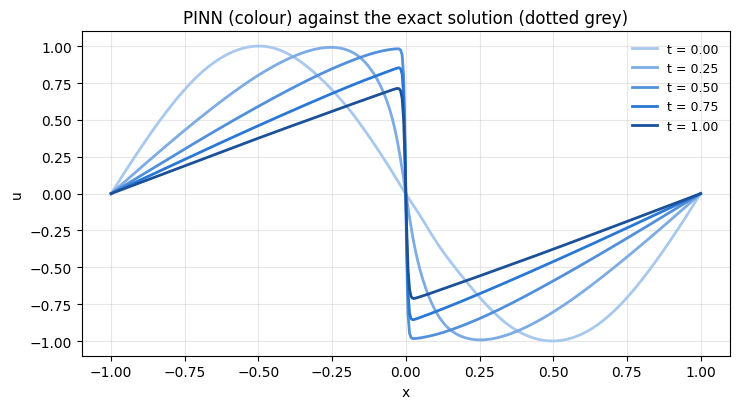

In [9]:
import matplotlib.pyplot as plt

x = torch.linspace(-1, 1, 400).reshape(-1, 1)
xs_np = x.numpy().ravel()
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ramp = ['#a8c8ee', '#7dabe4', '#5290db', '#2a78d6', '#1b5199']
for t_val, col in zip((0.0, 0.25, 0.5, 0.75, 1.0), ramp):
    with torch.no_grad():
        u = model(torch.full_like(x, t_val), x).numpy().ravel()
    ax.plot(xs_np, u, color=col, lw=2, label=f't = {t_val:.2f}')
    if t_val > 0:
        ax.plot(xs_np, burgers_exact(xs_np, t_val), color='#b9b8b3',
                lw=1, ls=':', zorder=0)
ax.set_xlabel('x'); ax.set_ylabel('u'); ax.grid(alpha=.3)
ax.legend(frameon=False, fontsize=9)
ax.set_title('PINN (colour) against the exact solution (dotted grey)')
plt.tight_layout(); plt.show()

## Exercises

1. Multiply `NU` by ten. The shock softens and everything converges faster. Now divide by
   ten instead and watch the method struggle — and watch the $L_2$ error, not the loss.
2. Replace `nn.Tanh` with `nn.ReLU`. Predict the failure before you run it.
3. Drop `n_f` to 500. How does the error against the exact solution move relative to the
   training loss? That gap is what module 08 is about.
4. Remove L-BFGS and give Adam 20 000 iterations instead. Compare accuracy and wall time.

---

Next: **02 — Why your loss will not go down**, where the equal weighting used here turns
out to be the single most expensive decision in the whole pipeline.